In [1]:
import numpy as np
from numpy.random import default_rng
from heat_experiment_2d import HeatExperiment2D
from random_shape import generate_line
%matplotlib widget

In [2]:
rng = default_rng()
def fake_response_function(terminal_time, timestep):
    x = np.linspace(0, 0.5, 30)
    rnum1 = rng.uniform(low=0.5, high=1.5)
    rnum2 = rng.uniform(low=0.5, high=1.5)
    y1 = rnum2*2*(1/(1+np.exp(-16*rnum1*x))-0.5)
    x = np.linspace(-0.5, 0, 30)
    y2 = -rnum2*2*(1/(1+np.exp(-16*rnum1*x))-0.5)
    y = np.append(y1, y2)
    y = np.append(y, np.zeros(40))
    x = np.linspace(0, 1, 100)
    
    t = np.arange(0, terminal_time+timestep, timestep)/terminal_time
    yt = np.interp(t, x, y)
    return yt

In [3]:
width, height = 100, 100
image_vein = generate_line(width, height)
vein_mask = ~np.array(image_vein, dtype=bool)
vein_fullness = 1
vein_mask = vein_fullness*vein_mask

In [4]:
blob_masks = []
diff_iron = 23e-6
terminal = 200
timestep = 0.1
node_x = width 
node_y = height #every pixel gets a node
diffusion_coefficient_matrix = np.zeros((node_x, node_y))
# vein
diffusion_coefficient_matrix = np.where(diffusion_coefficient_matrix == 0, vein_mask*diff_iron, diffusion_coefficient_matrix)
# space in between
diffusion_coefficient_matrix = np.where(diffusion_coefficient_matrix == 0, diff_iron, diffusion_coefficient_matrix)
vein_values = fake_response_function(terminal, timestep)

In [5]:
exp = HeatExperiment2D(terminal_time=terminal, timestep=timestep, vein_function_values = vein_values,
                        length_x=0.3, length_y=0.3, boundary_value=0, x_nodes=node_x, y_nodes=node_y,
                        vein_masks = [vein_mask], coefficient_matrix=diffusion_coefficient_matrix, initial_value=0, cmap='cmr.arctic')
exp.run_calculation()
exp.save_solution('exp1.npy')

In [6]:
# (exp.time_step*diffusion_coefficient_matrix/exp.dx**2).max()

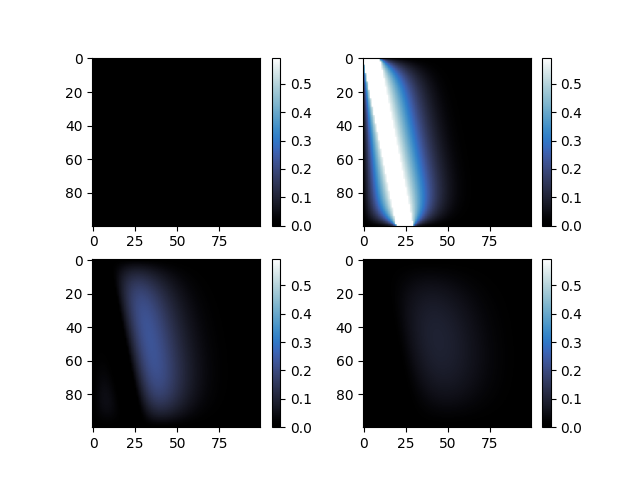

In [24]:
newxp = HeatExperiment2D()
sol = np.load('exp1.npy')
sol.shape
newxp.solution = sol
newxp.cmap = 'cmr.arctic'
newxp.visualize_snapshots()

In [9]:
# exp.visualize_animated(save=True, display=False)